In [14]:
import xarray_behave as xb
import matplotlib.pyplot as plt
import scipy
import numpy as np
import datetime
import pandas as pd

from tools import parse_log_file

plt.style.use('ncb.mplstyle')

In [89]:
datename='localhost-20260402_130508'
root='/Volumes/agauneu/#Data/playback'
suffix = '_2' # or ''

ds = xb.assemble(datename=datename, root=root, target_sampling_rate=1_000, resample_video_data=True, filepath_poses=f"{root}/res/{datename}/{datename}{suffix}_sleap.h5", filepath_video=f"{root}/res/{datename}/{datename}{suffix}_sleap.h5")
nb_flies = len(ds.flies)
ds

   Failed loading movie params - no ss_movie


<xarray.Dataset> Size: 3GB
Dimensions:              (sampletime: 17995000, channels: 1, time: 3597984,
                          event_types: 0, event_time: 3, index: 0,
                          poseparts: 2, coords: 2, flies: 10)
Coordinates:
  * sampletime           (sampletime) float64 144MB 0.0 0.0002 ... 3.599e+03
  * time                 (time) float64 29MB 0.0 0.0009999 ... 3.598e+03
    nearest_frame        (time) int64 29MB 304 305 305 ... 216173 216173 216173
  * event_types          (event_types) float64 0B 
    event_categories     (event_types) float64 0B 
  * event_time           (event_time) <U13 156B 'start_seconds' ... 'channels'
  * poseparts            (poseparts) <U4 32B 'head' 'tail'
  * coords               (coords) <U1 8B 'y' 'x'
Dimensions without coordinates: channels, index, flies
Data variables:
    song_raw             (sampletime, channels) float64 144MB 4.02e-05 ... -0...
    song_events          (time, event_types) int16 0B 
    event_times          (index, event_time) float64 0B 
    event_names          (index) <U128 0B 
    pose_positions       (time, flies, poseparts, coords) float64 1GB 0.0 ......
    pose_positions_allo  (time, flies, poseparts, coords) float64 1GB 629.6 ....
Attributes:
    video_filename:           /Volumes/agauneu/#Data/playback/dat/localhost-2...
    datename:                 localhost-20260402_130508
    root:                     /Volumes/agauneu/#Data/playback
    dat_path:                 dat
    res_path:                 res
    sampling_rate_Hz:         5000.0
    target_sampling_rate_Hz:  1000
    ref_time:                 1775127920.2991

### Parse logs

In [90]:
logs = parse_log_file(f"{root}/dat/{datename}/{datename}_daq.log")
stim_names = [s[0] for s in logs['stimFileName']]
logs.head()

,timestamp,rig,cnt,stimFileName,silencePre,silencePost,delayPost,intensity,freq,MODE
0,2026-04-02 13:05:20.264,DAQ@PC-845393,1,[santune_ipi70_pulseTrain_PDUR30ms_PCAR170hz_P...,[30000],[30000],[0],[6.0],[200.0],[nan]
1,2026-04-02 13:06:22.855,DAQ@PC-845393,2,[santune_ipi38_pulseTrain_PDUR30ms_PCAR170hz_P...,[30000],[30000],[0],[6.0],[200.0],[nan]
2,2026-04-02 13:07:26.857,DAQ@PC-845393,3,[santune_ipi130_pulseTrain_PDUR30ms_PCAR170hz_...,[30000],[30000],[0],[6.0],[200.0],[nan]
3,2026-04-02 13:08:30.860,DAQ@PC-845393,4,[santune_ipi70_pulseTrain_PDUR30ms_PCAR170hz_P...,[30000],[30000],[0],[6.0],[200.0],[nan]
4,2026-04-02 13:09:34.862,DAQ@PC-845393,5,[santune_ipi38_pulseTrain_PDUR30ms_PCAR170hz_P...,[30000],[30000],[0],[6.0],[200.0],[nan]


### Compute speed

/var/folders/zr/6ql4dzjx0tq8mpzht_2dwh480000gn/T/ipykernel_78558/1655572023.py:1: RuntimeWarning: Mean of empty slice
  pos = np.nanmean(ds.pose_positions_allo, axis=-2)


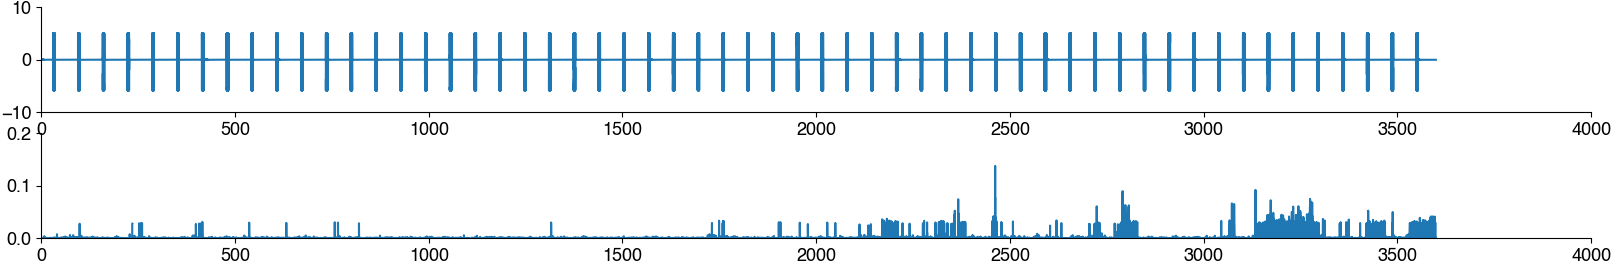

In [127]:
pos = np.nanmean(ds.pose_positions_allo, axis=-2)
speed_raw = np.linalg.norm(xb.metrics.velocity(pos), axis=-1)
speed = scipy.signal.medfilt(speed_raw, 5)

plt.figure(figsize=(20, 3))
plt.subplot(211)
plt.plot(ds.sampletime, ds.song_raw[:, 0])

plt.subplot(212)
# plt.plot(ds.time, speed_raw[:, 0])
plt.plot(ds.time, speed[:, 0])
plt.show()

### Detect stimulus on and offsets

In [109]:
fs = ds.attrs['target_sampling_rate_Hz']
win_len = int(0.05 * fs)
window = scipy.signal.windows.gaussian(win_len, win_len // 8)
window /= np.sum(window)

env = np.sqrt(np.convolve(ds.song_raw[:, 0]**2, window, mode='full'))
env = env[win_len//2:win_len//2 + ds.song_raw.shape[0]]

In [110]:
thres = 1
stim = scipy.ndimage.binary_closing(env>thres, np.ones(1001))
stim_diff = np.diff(stim, prepend=0).astype(float)
stim_onsets = np.where(stim_diff==1)[0]
stim_offsets = np.where(stim_diff==-1)[0]

onset_times = ds.sampletime[stim_onsets]
offset_times = ds.sampletime[stim_offsets]


In [ ]:

plt.plot(np.diff(onset_times))
plt.plot(np.diff(offset_times))
plt.ylim(0)

NameError: name 'plt' is not defined

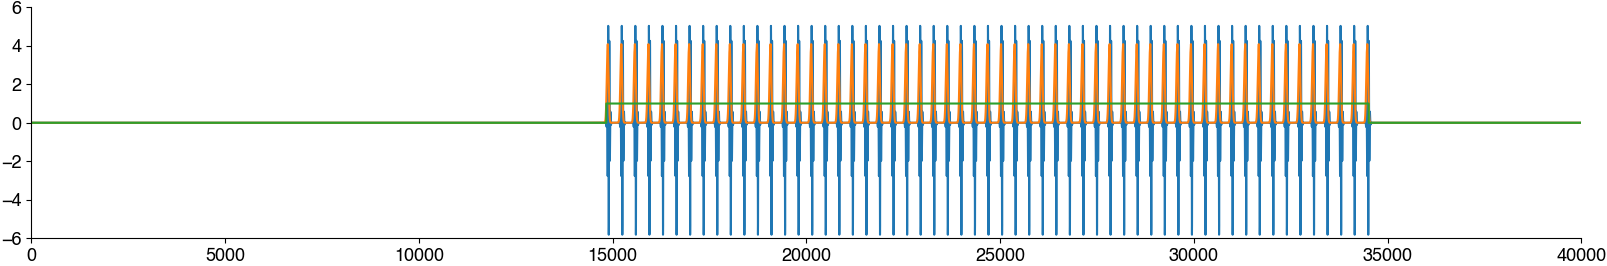

(0.0, 1000.0)

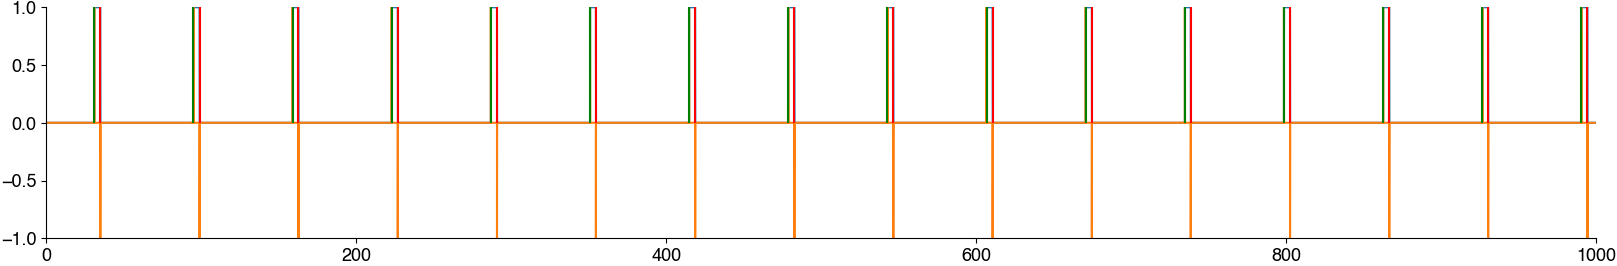

In [111]:
plt.figure(figsize=(20, 3))
plt.plot(ds.song_raw[140_000:180_000, 0])
plt.plot(env[140_000+win_len//2:180_000+win_len//2])
plt.plot(stim[140_000+win_len//2:180_000+win_len//2])
plt.show()

plt.figure(figsize=(20, 3))
plt.plot(ds.sampletime, stim)
plt.plot(ds.sampletime, stim_diff)
plt.vlines(onset_times, 0, 1, color='g')
plt.vlines(offset_times, 0, 1, color='r')
plt.xlim(0, 1000)

In [117]:
fs = ds.attrs['target_sampling_rate_Hz']
prefix = int(5 * fs)
duration = int(10 * fs)

all_traces = np.zeros((len(stim_onsets), prefix + duration, nb_flies))
for cnt, onset_time in enumerate(onset_times):
    onset_idx = np.argmax(ds.time.data[:, np.newaxis]>=onset_time.data)
    all_traces[cnt, :, :] = speed[onset_idx - prefix:onset_idx + duration, :]

all_traces = np.array(all_traces)

In [ ]:
time = np.arange(-prefix, duration) / fs
time

(56, 10)

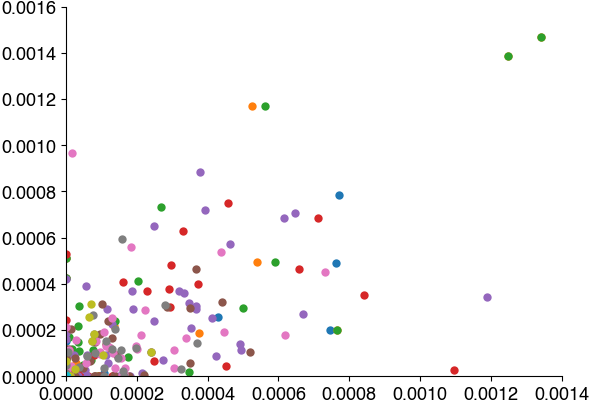

In [118]:
baseline_speed = np.nanmedian(all_traces[:, :prefix ,:], axis=1)
response_speed = np.nanmedian(all_traces[:, prefix: prefix+5 * fs ,:], axis=1)
plt.plot(baseline_speed, response_speed, 'o')
baseline_speed.shape

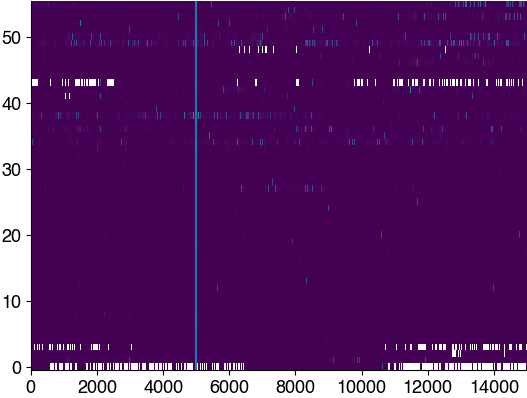

In [119]:
plt.imshow(np.array(all_traces)[..., 1])
plt.axvline(prefix / fs * ds.attrs['target_sampling_rate_Hz'])

santune_ipi70_pulseTrain_PDUR30ms_PCAR170hz_PPAU40ms_TDUR4s_NPUL57.wav
santune_ipi130_pulseTrain_PDUR30ms_PCAR170hz_PPAU100ms_TDUR4s_NPUL30.wav
santune_ipi38_pulseTrain_PDUR30ms_PCAR170hz_PPAU8ms_TDUR4s_NPUL105.wav


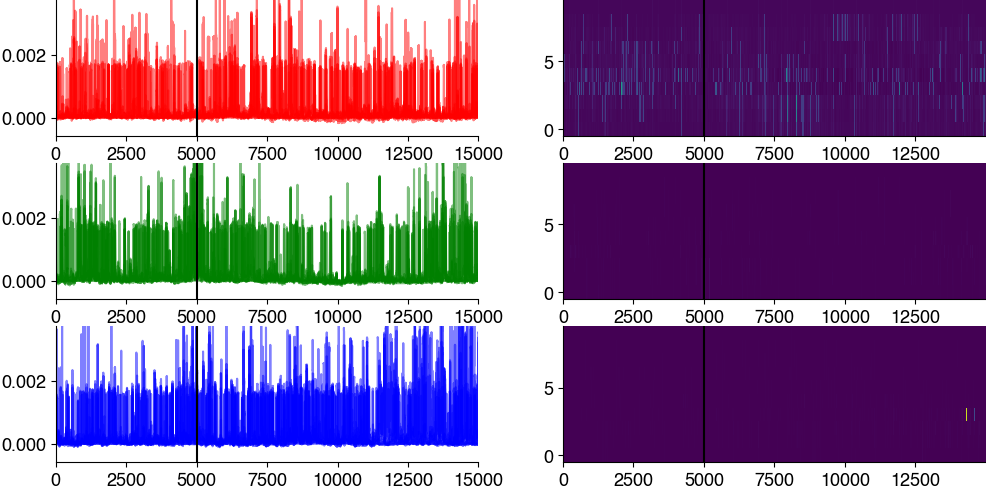

In [125]:
stim_names = np.array([s[0] for s in logs['stimFileName'][:-1]])
uni_stim_names = set(stim_names)

S = all_traces
S = S  - baseline_speed[:, np.newaxis, :]
plt.figure(figsize=(12, 6))
for cnt, (name, col) in enumerate(zip(uni_stim_names, 'rgb')):
    print(name)
    this_idx = stim_names == name

    plt.subplot(len(uni_stim_names), 2, cnt * 2+2)
    plt.imshow(np.nanmean(S[this_idx, ...], axis=0).T)
    plt.axvline(prefix, c='k')

    plt.subplot(len(uni_stim_names), 2, cnt * 2+1)
    plt.plot(np.nanmean(S[this_idx, ...], axis=0), c=col, alpha=0.5)
    plt.axvline(prefix, c='k')
    plt.ylim(*np.nanpercentile(S,[1, 99]))
plt.show()
